<a href="https://colab.research.google.com/github/Rahul-lab826/AI-Training/blob/main/Stroke_neural_networking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import sklearn.datasets

In [ ]:
df=pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [ ]:
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
median_bmi = df['bmi'].median()
df['bmi'].fillna(median_bmi, inplace=True)
display(df.isna().sum())

/tmp/ipykernel_455/965649465.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(median_bmi, inplace=True)


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [ ]:
x=df.drop(columns='stroke',axis=1)
y=df['stroke']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

x_train = x_train.drop('id', axis=1)
x_test = x_test.drop('id', axis=1)

categorical_cols = x_train.select_dtypes(include='object').columns

x_train_encoded = pd.get_dummies(x_train, columns=categorical_cols, drop_first=True)
x_test_encoded = pd.get_dummies(x_test, columns=categorical_cols, drop_first=True)

train_cols = x_train_encoded.columns
x_test_encoded = x_test_encoded.reindex(columns=train_cols, fill_value=0)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_encoded)
x_test_scaled = scaler.transform(x_test_encoded)

In [ ]:
display(pd.DataFrame(x_train_scaled, columns=x_train_encoded.columns))

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.584155,-0.321981,-0.236189,0.135593,-0.054102,1.192995,0.726005,-0.070117,-1.153548,2.285218,-0.389710,-1.023265,2.177515,-0.764122,-0.429233
1,0.829708,-0.321981,-0.236189,-0.397457,0.951155,-0.838227,0.726005,-0.070117,0.866891,-0.437595,-0.389710,0.977264,-0.459239,-0.764122,-0.429233
2,-0.989841,-0.321981,-0.236189,-1.028701,0.616069,-0.838227,-1.377402,-0.070117,0.866891,-0.437595,-0.389710,-1.023265,-0.459239,1.308692,-0.429233
3,-0.546049,-0.321981,-0.236189,-0.893246,0.190768,1.192995,0.726005,-0.070117,-1.153548,-0.437595,-0.389710,0.977264,2.177515,-0.764122,-0.429233
4,-0.546049,-0.321981,-0.236189,-1.026290,-1.162462,-0.838227,-1.377402,-0.070117,0.866891,-0.437595,-0.389710,-1.023265,-0.459239,1.308692,-0.429233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4083,-0.013498,-0.321981,-0.236189,-0.404471,0.216544,1.192995,0.726005,-0.070117,-1.153548,-0.437595,-0.389710,-1.023265,-0.459239,1.308692,-0.429233
4084,0.785328,3.105774,-0.236189,1.393916,4.031365,-0.838227,0.726005,-0.070117,0.866891,-0.437595,-0.389710,-1.023265,-0.459239,-0.764122,2.329737
4085,-1.870325,-0.321981,-0.236189,-0.201070,-1.433108,-0.838227,-1.377402,-0.070117,-1.153548,-0.437595,2.566012,0.977264,-0.459239,-0.764122,-0.429233
4086,1.628534,-0.321981,-0.236189,1.964446,0.268096,1.192995,0.726005,-0.070117,-1.153548,2.285218,-0.389710,-1.023265,2.177515,-0.764122,-0.429233


In [ ]:
display(pd.DataFrame(x_test_scaled, columns=x_test_encoded.columns))

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,-0.546049,-0.321981,-0.236189,-0.911877,-0.762937,1.192995,-1.377402,-0.070117,-1.153548,2.285218,-0.389710,-1.023265,-0.459239,-0.764122,-0.429233
1,-0.146636,-0.321981,-0.236189,-0.902233,-0.079878,1.192995,0.726005,-0.070117,-1.153548,2.285218,-0.389710,-1.023265,-0.459239,1.308692,-0.429233
2,-1.566771,-0.321981,-0.236189,-0.702120,-0.827377,-0.838227,-1.377402,-0.070117,-1.153548,-0.437595,2.566012,0.977264,-0.459239,-0.764122,-0.429233
3,1.584155,3.105774,-0.236189,-0.653462,-1.214014,-0.838227,0.726005,-0.070117,-1.153548,2.285218,-0.389710,-1.023265,-0.459239,1.308692,-0.429233
4,1.406638,-0.321981,-0.236189,-0.256085,-0.221645,-0.838227,0.726005,-0.070117,-1.153548,-0.437595,-0.389710,-1.023265,-0.459239,1.308692,-0.429233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,-1.838372,-0.321981,-0.236189,0.822290,-0.105654,1.192995,-1.377402,-0.070117,-1.153548,-0.437595,2.566012,-1.023265,-0.459239,-0.764122,-0.429233
1018,-1.863225,-0.321981,-0.236189,0.012413,-0.105654,1.192995,-1.377402,-0.070117,-1.153548,-0.437595,2.566012,-1.023265,-0.459239,-0.764122,-0.429233
1019,0.252778,3.105774,-0.236189,0.281568,0.190768,1.192995,0.726005,-0.070117,-1.153548,2.285218,-0.389710,-1.023265,2.177515,-0.764122,-0.429233
1020,0.563432,-0.321981,-0.236189,0.486065,-0.518067,-0.838227,-1.377402,-0.070117,-1.153548,2.285218,-0.389710,0.977264,-0.459239,-0.764122,2.329737


In [17]:
import tensorflow as tf
from tensorflow import keras

In [18]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(14,)),
    keras.layers.Dense(10,activation='relu'),
    keras.layers.Dense(2,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [21]:
import tensorflow as tf
from tensorflow import keras

model=keras.Sequential([
    keras.layers.Flatten(input_shape=(x_train_scaled.shape[1],)),
    keras.layers.Dense(10,activation='relu'),
    keras.layers.Dense(2,activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train_scaled,y_train,validation_split=0.1,epochs=80)

Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3993 - loss: 1.0526 - val_accuracy: 0.7335 - val_loss: 0.6033
Epoch 2/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8714 - loss: 0.4149 - val_accuracy: 0.9267 - val_loss: 0.3231
Epoch 3/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9345 - loss: 0.2621 - val_accuracy: 0.9389 - val_loss: 0.2535
Epoch 4/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9478 - loss: 0.2154 - val_accuracy: 0.9438 - val_loss: 0.2262
Epoch 5/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9530 - loss: 0.1942 - val_accuracy: 0.9462 - val_loss: 0.2114
Epoch 6/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9538 - loss: 0.1819 - val_accuracy: 0.9462 - val_loss: 0.2022
Epoch 7/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9543 - loss: 0.1741 - val_accuracy: 0.9438 - val_loss: 0.1957
Epoch 8/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9543 - loss: 0.1688 - val_accuracy: 0.9438 - val_

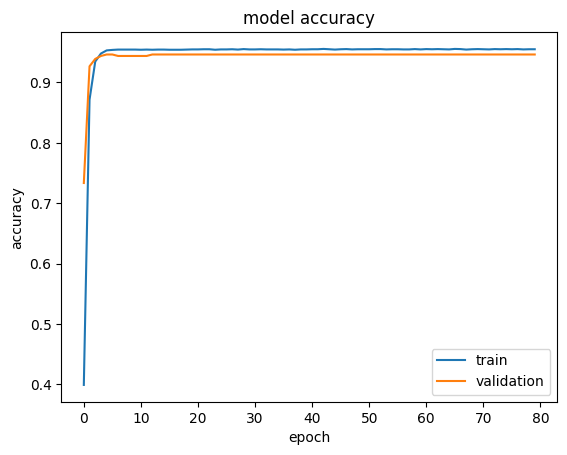

In [22]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.show()

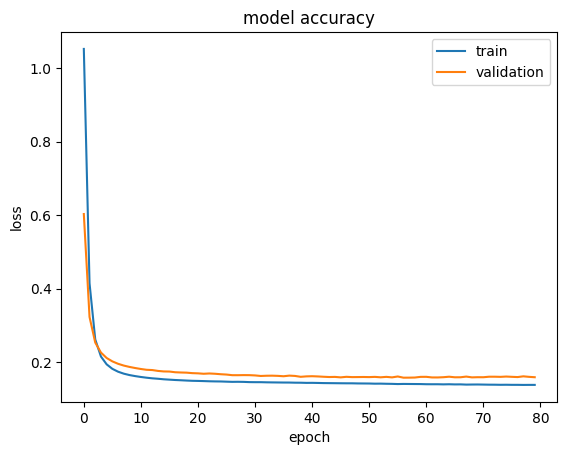

In [23]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('model accuracy')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()